# **Atividade Prática**
<font size=3>

- **Tema:** Regressão linear e logística.
- **Prazo de entrega:** 26 de Março.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=publish-editor).

---

## **Questão 1:**
<font size=3>

Resolva a tarefa de **regressão** do *dataset* [`fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) com o modelo [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Siga o **fluxo de trabalho** de aprendizado de máquina, descrito na aula.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler


X-train:(14447, 8), y-train:(14447,)
X-test:(6192, 8), y-test:(6192,)


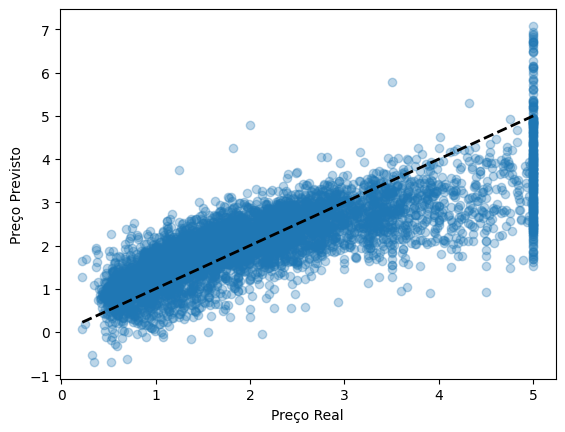

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:


california = fetch_california_housing() 
X = california.data 
Y = california.target 

df = pd.DataFrame(X, columns=california.feature_names) 
df["MedHouseVal"] = Y

x_train, x_test, y_train, y_test = train_test_split(X,Y , test_size=0.3, train_size=0.7) 

print(f"X-train:{x_train.shape}, y-train:{y_train.shape}") 
print(f"X-test:{x_test.shape}, y-test:{y_test.shape}")


scale = StandardScaler() 
model = LinearRegression()

x_train_scale = scale.fit_transform(x_train) 
x_test_scale = scale.transform(x_test) 

model.fit(x_train_scale,y_train)


y_pred_test = model.predict(x_test_scale) 

plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")

plt.show()

df.head()

## **Questão 2:**
<font size=3>

Resolva a tarefa de **classificação** do *dataset* [`load_iris`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) com o modelo [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Siga o **fluxo de trabalho** de aprendizado de máquina, descrito na aula.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

X-train:(105, 2), y-train:(105,)
X-test:(45, 2), y-test:(45,)


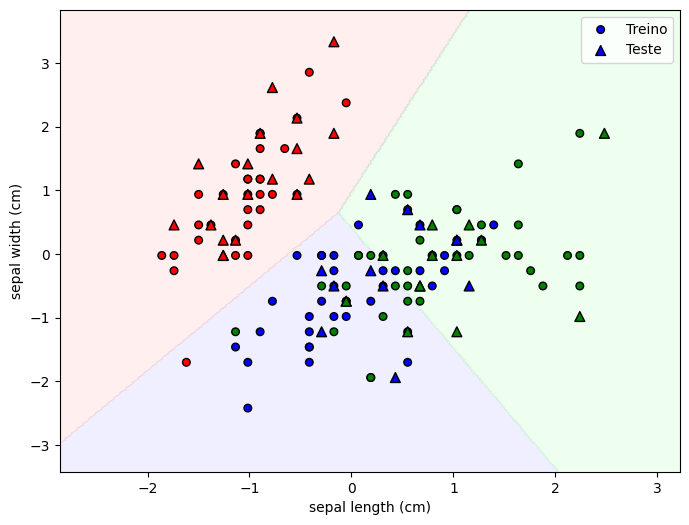

Acurácia: 0.82


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [13]:

iris = load_iris()
X = iris.data[:, :2]
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X-train:{x_train.shape}, y-train:{y_train.shape}") 
print(f"X-test:{x_test.shape}, y-test:{y_test.shape}")

df = pd.DataFrame(X, columns=iris.feature_names[:2]) 


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LogisticRegression(max_iter=2000)
model.fit(x_train, y_train)

x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
atri1, atri2 = np.meshgrid(np.arange(x_min, x_max, 0.02),
                           np.arange(y_min, y_max, 0.02))

z = model.predict(np.c_[atri1.ravel(), atri2.ravel()])
z = z.reshape(atri1.shape)

cmap_fundo = ListedColormap(["#FFCCCC", "#CCCCFF", "#CCFFCC"]) 
cmap_pontos = ListedColormap(["red", "blue", "green"])

plt.figure(figsize=(8, 6))
plt.contourf(atri1, atri2, z, alpha=0.3, cmap=cmap_fundo)

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap=cmap_pontos,
            edgecolor="k", s=30, label="Treino")
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap=cmap_pontos,
            marker="^", edgecolor="k", s=50, label="Teste")

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()

y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")

df.head()